# CNN on Mugs Dataset

This notebook implements a **Convolutional Neural Network (CNN)** for our own **Mugs** dataset.

## Goals

- Load and preprocess the **Mugs** dataset
- Create a **CNN** architecture suitable for image classification
- Train the **CNN** on the training set and validate on the validation set
- Evaluate performance on the test set
- Analyze results

## Notes
- The project consists of 3 implementations:
  - **CNN from scratch** (this notebook)
  - **Feature extraction with a pre-trained model** (feature-extraction.ipynb)
  - **Fine-tuning a pre-trained model** (fine-tuned.ipynb)

In [41]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import time
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers

from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Data Preparation

We use our own **Mugs** dataset, which contains images from three classes:

- **Coffee Mugs**
- **Drinking Glasses**
- **Wine Glasses**

The dataset includes images of individual objects photographed in two different environments. For each unique object, **three images** were taken from different viewing angles or orientations. The dataset contains **26 coffee mugs** (78 images), **26 drinking glasses** (78 images), and **18 wine glasses** (54 images), for a total of **210 images**.

The data was manually divided into **training**, **validation**, and **test** sets with an approximately **70/15/15 split**. The split was created at the **object level**, meaning that images of the same physical object do not appear in multiple sets. This helps prevent **data leakage** and ensures that the model is evaluated on previously unseen objects rather than different views of objects already seen during training. Since the images were captured in two different environments, the split was also balanced so that each set contains images from both backgrounds.

The original images have a **3:4 aspect ratio** and come in two resolutions: **3468 × 4624** and **3120 × 4160** pixels. For training, the images are resized to **224 × 224** pixels. Because the CNN requires a fixed input size, the images are first **center-cropped to a square aspect ratio** and then resized. In the implementation, this is done using `crop_to_aspect_ratio=True`, which preserves the central part of the image while avoiding distortion caused by direct resizing. All images are loaded in **RGB format**, resulting in input tensors with shape **224 × 224 × 3**.

The dataset is loaded with `keras.utils.image_dataset_from_directory`, which automatically infers class labels from the folder structure. Labels are encoded using `label_mode="categorical"`.

In [42]:
# Load the dataset
img_size = (224, 224)
num_classes = 3
batch_size = 16
seed = 123
data_dir = "/home/valvoja/projects/2026-Spring-Neural-Network-Project/dataset-mug"

common_args = dict(
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    crop_to_aspect_ratio=True
)

train_ds = keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    shuffle=True,
    seed=seed,
    **common_args
)

val_ds = keras.utils.image_dataset_from_directory(
    f"{data_dir}/val",
    shuffle=False,
    **common_args
)

test_ds = keras.utils.image_dataset_from_directory(
    f"{data_dir}/test",
    shuffle=False,
    **common_args
)

Found 144 files belonging to 3 classes.
Found 33 files belonging to 3 classes.
Found 33 files belonging to 3 classes.


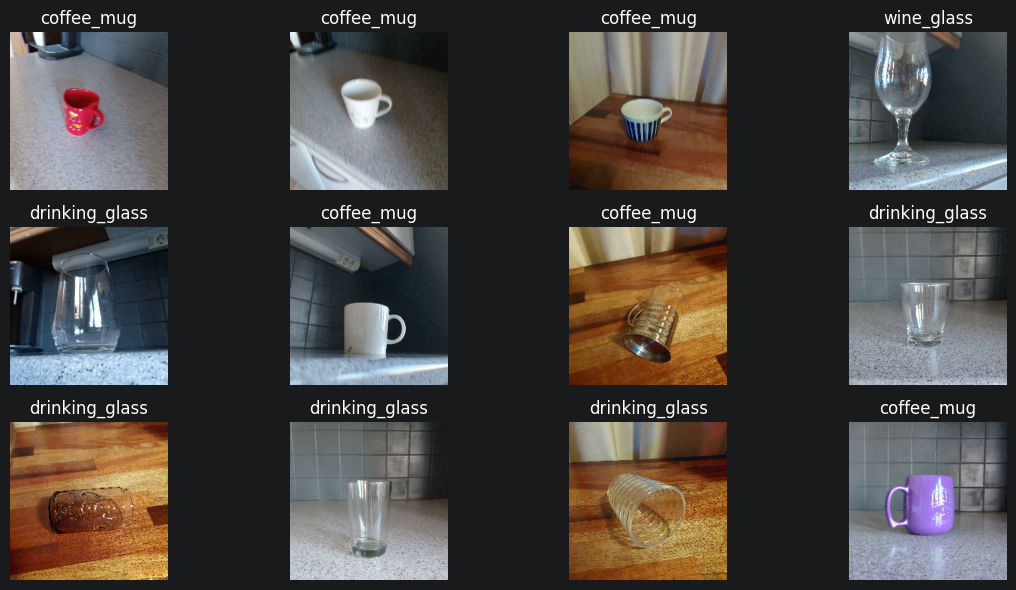

In [43]:
# Show a few sample images from the training set
class_names = train_ds.class_names
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i].numpy())])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Augmentation

To improve generalization, we apply data augmentation to the training images. We are using random horizontal flipping and small random rotations. Other augmentations like zooming and translation were tested, but they did not improve performance, so they were commented out.

In [44]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    #layers.RandomZoom(0.08),
    #layers.RandomTranslation(0.05, 0.05)
], name="data_augmentation")

augmenter

<Sequential name=data_augmentation, built=False>

## CNN Model

This model includes:
- **Data augmentation** layer to apply random horizontal flips and small rotations during training.
- **Rescaling** layer to normalize pixel values to the [0, 1] range
- **4 Convolutional layers** with increasing filter sizes **(32, 64, 128, 256)** and relu activation, each followed by MaxPooling.
- **GlobalAveragePooling** to reduce the spatial dimensions before the dense layers.
- **Dropout** layer with a rate of **0.35** was found to be effective in preventing overfitting.

In [45]:
inputs = keras.Input(shape=img_size + (3,))

x = augmenter(inputs)
x = layers.Rescaling(1.0 / 255)(x)

x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="mugs_cnn")

model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

In [46]:
model.summary()

Model: "mugs_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,187 (1.48 MB)

 Trainable params: 389,187 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [47]:
callbacks = [
    ModelCheckpoint(filepath="mugs_cnn.keras", save_best_only=True, monitor="val_loss"),
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

In [48]:
# Training
batch_size = 8
epochs = 100

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks
)

training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.3819 - loss: 1.0999 - val_accuracy: 0.3636 - val_loss: 1.0938 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.3403 - loss: 1.0958 - val_accuracy: 0.3636 - val_loss: 1.0964 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.3264 - loss: 1.0901 - val_accuracy: 0.3636 - val_loss: 1.0948 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3949 - loss: 1.0877
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.4028 - loss: 1.0902 - val_accuracy: 0.3636 - val_loss: 1.0956 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.4236 - loss: 1.0873 - val_accuracy: 0.3939 - val_loss: 1.0938 - learning_rate: 5.0000e-04
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.3681 - loss: 1.0898 - val_a

## Evaluation

Evaluation is done on the best performing model saved during training.

Evaluation will include:
- Learning curves for training and validation loss and accuracy.
- Test set performance (loss and accuracy).
- Classification report with precision, recall, and F1-score for each class.
- Confusion matrix to visualize the performance across classes.

In [49]:
best_model = keras.models.load_model("mugs_cnn.keras")

### Learning curves

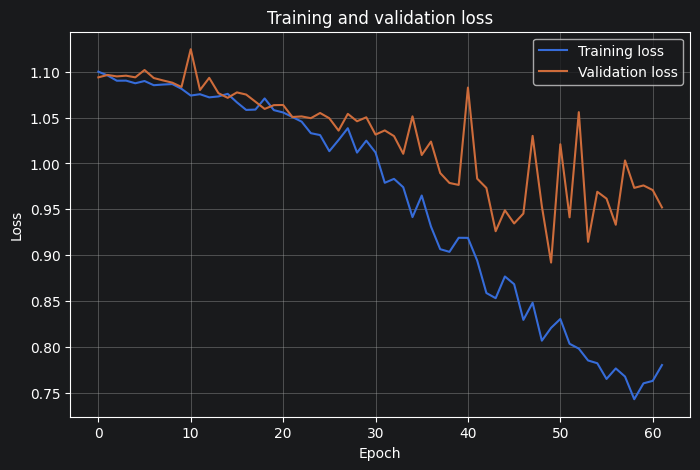

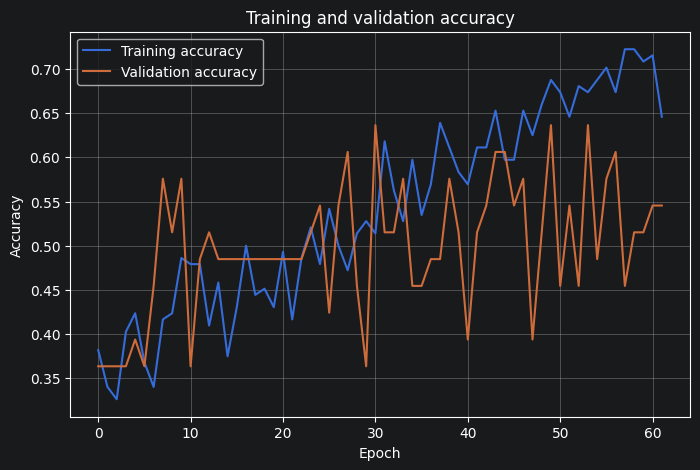

In [50]:
# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation on test set

In [51]:
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.9028
Test accuracy: 0.6970


### Classification report

In [52]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_true, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

                precision    recall  f1-score   support

    coffee_mug       0.64      0.75      0.69        12
drinking_glass       0.83      0.83      0.83        12
    wine_glass       0.57      0.44      0.50         9

      accuracy                           0.70        33
     macro avg       0.68      0.68      0.68        33
  weighted avg       0.69      0.70      0.69        33



### Confusion matrix

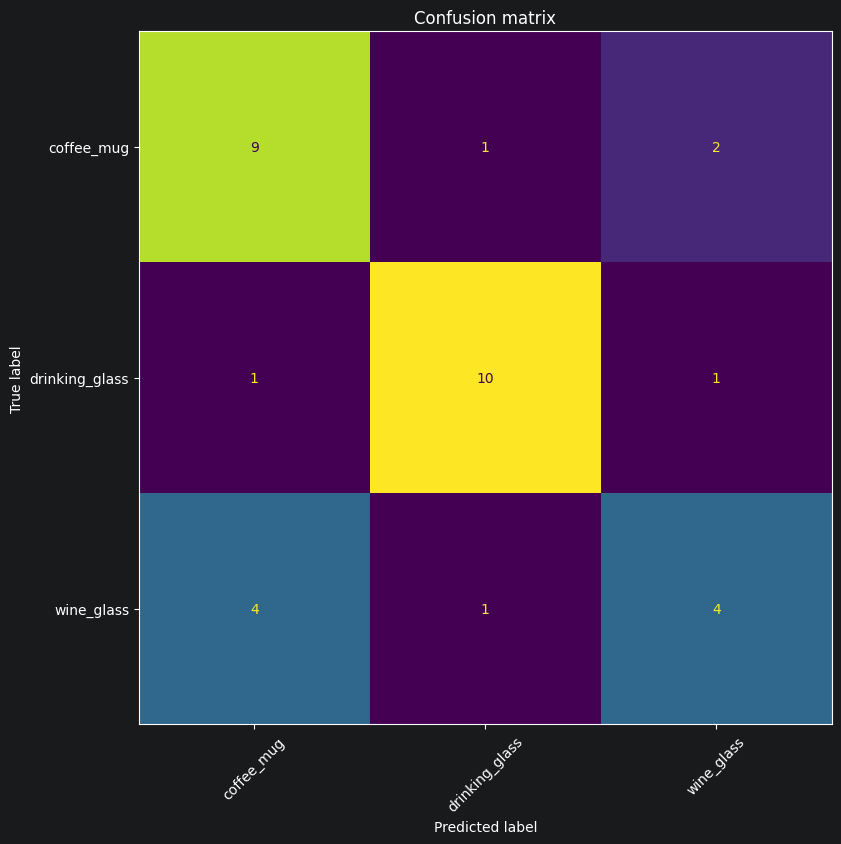

In [53]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Confusion matrix")
plt.show()

## Conclusion

The CNN model achieves a highly varying performance across different runs due to the small dataset size and the complexity of the task. The best models achieve a **test accuracy of around 70%**, while other runs can be significantly lower. On some runs the model fails to learn meaningful features and collapses to always predicting mostly only one class, usually leaving **Wine Glasses** completely unrecognized. All of these issues are likely due to the small dataset size.

We tried various techniques to improve performance, including data augmentation, dropout, tuning the learning rate, and adding different weights based on amount of data per class. However, the results were still highly variable and the best runs were accomplished with the current relatively simple architecture and training setup.

Since different runs yield very different results, we couldn't do a detailed analysis on the evaluation results as they differ significantly between runs. However, the best performing models generally show good performance on **Coffee Mugs** and **Drinking Glasses**, while struggling with **Wine Glasses**. This could be due to the smaller number of **Wine Glasses** in the dataset.